# 🧠 Lab 0 — ML Pipeline Review: Scikit-learn & PyTorch

**Teaching Assistant** : Eleonora Poeta (eleonora.poeta@polito.it)

---
This unified lab walks through the **complete ML workflow** using two complementary frameworks:

| Part | Framework | Task |
|------|-----------|------|
| **Part 1** | Pandas + Scikit-learn | Titanic survival prediction (binary classification) |
| **Part 2** | PyTorch | Digits recognition (multi-class classification) |

**Estimated time:** 1.5 hours  
**Goal:** By the end you will be able to preprocess tabular data, train classical ML models, and build + train a neural network from scratch in PyTorch.

---

## 📦 Part 1 — ML Pipeline with Pandas & Scikit-learn

A typical ML pipeline involves these steps:
1. **Load & explore** the data
2. **Split** into train/test (with stratification)
3. **Clean**: handle missing values, remove duplicates
4. **Encode** categorical features
5. **Scale** numerical features
6. **Train & evaluate** one or more classifiers

> ⚠️ Always fit transformers **only on the training set**, then apply them to both sets to avoid data leakage.

### 1.1 — Imports

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression as LR_sklearn
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded")

✅ Libraries loaded


### 1.2 — Load the Titanic Dataset

The [Titanic dataset](https://www.kaggle.com/c/titanic) contains passenger information and whether they survived.  
We want to predict the column **`survived`** (0 = no, 1 = yes).

In [2]:
# Load dataset from OpenML
df, y = fetch_openml('titanic', version=1, as_frame=True, parser='auto', return_X_y=True)
df["survived"] = y.astype(int)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1309, 14)


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


In [3]:
# Quick overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   str     
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   str     
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    str     
 9   embarked   1307 non-null   category
 10  boat       486 non-null    str     
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    str     
 13  survived   1309 non-null   int64   
dtypes: category(2), float64(3), int64(4), str(5)
memory usage: 125.4 KB


In [4]:
# Class balance — important for choosing metrics!
print("Class distribution:")
print(df["survived"].value_counts())
print(f"\nImbalance ratio: {df['survived'].value_counts()[0]/df['survived'].value_counts()[1]:.2f}:1")

Class distribution:
survived
0    809
1    500
Name: count, dtype: int64

Imbalance ratio: 1.62:1


### 1.3 — Train / Test Split with Stratification

Because the dataset is **imbalanced**, we use `stratify=` to preserve the class ratio in both splits.

In [5]:
#### START CODE HERE ####
# Split 80% train / 20% test, shuffle=True, random_state=42, stratify by 'survived'
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=True, random_state=42, stratify=df["survived"])
#### END CODE HERE ####

print(f"Train: {len(df_train)} samples | Test: {len(df_test)} samples")
print("\nTrain class distribution:")
print(df_train["survived"].value_counts())

Train: 1047 samples | Test: 262 samples

Train class distribution:
survived
0    647
1    400
Name: count, dtype: int64


### 1.4 — Handle Missing Values

**Rule:** compute statistics (mean, median…) on the **training set only**, then apply to both sets.

In [6]:
# Count NaN per column
nan_train = df_train.isna().sum()
nan_test  = df_test.isna().sum()

print("Missing values — Train:")
print(nan_train[nan_train > 0])
print("\nMissing values — Test:")
print(nan_test[nan_test > 0])

Missing values — Train:
age          209
fare           1
cabin        822
boat         658
body         955
home.dest    450
dtype: int64

Missing values — Test:
age           54
cabin        192
embarked       2
boat         165
body         233
home.dest    114
dtype: int64


In [7]:
#### START CODE HERE ####
# Fill 'age' NaN with the TRAINING mean
df_train['age'] = df_train['age'].fillna(df_train['age'].mean())
df_test['age'] = df_test['age'].fillna(df_train['age'].mean())

# Fill 'fare' NaN with the TRAINING median
df_train['fare'] = df_train['fare'].fillna(df_train['fare'].median())
df_test['fare'] = df_test['fare'].fillna(df_train['fare'].median())

# Drop columns with too many missing values or that are not useful
cols_to_drop = ['boat', 'body', 'home.dest', 'cabin', 'ticket', 'name']
df_train.drop(columns=cols_to_drop, inplace=True, errors='ignore')
df_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')
#### END CODE HERE ####

# Fill remaining categorical NaN with the most frequent value
for col in ['embarked']:
    most_freq = df_train[col].mode()[0]
    df_train[col] = df_train[col].fillna(most_freq)
    df_test[col] = df_test[col].fillna(most_freq)

print(f"Remaining NaN — Train: {df_train.isna().sum().sum()} | Test: {df_test.isna().sum().sum()}")

Remaining NaN — Train: 0 | Test: 0


### 1.5 — Encode Categorical Features

ML models require **numerical** inputs.  
We use **Label Encoding** (binary categories) and **One-Hot Encoding** (multi-value categories).

In [8]:
# Label-encode binary categorical column 'sex'
le = LabelEncoder()
le.fit(df_train['sex'])
df_train['sex'] = le.transform(df_train['sex'])
df_test['sex']  = le.transform(df_test['sex'])

# One-hot encode 'embarked' (S, C, Q)
df_train = pd.get_dummies(df_train, columns=['embarked'], drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=['embarked'], drop_first=True)

# Align columns (test may be missing a column if a category is absent)
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

print("Columns after encoding:", df_train.columns.tolist())

Columns after encoding: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived', 'embarked_Q', 'embarked_S']


### 1.6 — Feature Selection & Standardization

We keep a subset of informative features and apply `StandardScaler` (zero mean, unit variance).

In [9]:
feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
                'embarked_Q', 'embarked_S']

X_train = df_train[feature_cols].astype(float)
X_test  = df_test[feature_cols].astype(float)

y_train = df_train['survived'].astype(int)
y_test  = df_test['survived'].astype(int)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_test  = scaler.transform(X_test)        # only transform on test

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (1047, 8) | X_test shape: (262, 8)


### 1.7 — Train & Evaluate Classifiers

We train three models and compare them using **precision, recall, F1-score** and the **confusion matrix**.

> 💡 Because the dataset is imbalanced, **accuracy alone is misleading** — prefer F1 score.

In [10]:
labels = ["Not-Survived", "Survived"]

# ── Decision Tree ────────────────────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("=" * 45)
print("Decision Tree")
print("=" * 45)
print(classification_report(y_test, y_pred_dt, target_names=labels))

Decision Tree
              precision    recall  f1-score   support

Not-Survived       0.82      0.93      0.87       162
    Survived       0.86      0.66      0.75       100

    accuracy                           0.83       262
   macro avg       0.84      0.80      0.81       262
weighted avg       0.83      0.83      0.82       262



In [11]:
# ── Random Forest ────────────────────────────────────────────
#### START CODE HERE ####
# Train a RandomForestClassifier (max_depth=5) and print its classification report
rf_model = RandomForestClassifier(max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
#### END CODE HERE ####

print("=" * 45)
print("Random Forest")
print("=" * 45)
print(classification_report(y_test, y_pred_rf, target_names=labels))

Random Forest
              precision    recall  f1-score   support

Not-Survived       0.85      0.91      0.88       162
    Survived       0.84      0.74      0.79       100

    accuracy                           0.85       262
   macro avg       0.85      0.83      0.83       262
weighted avg       0.85      0.85      0.85       262



In [12]:
# ── Logistic Regression ──────────────────────────────────────
lr_model = LR_sklearn(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("=" * 45)
print("Logistic Regression")
print("=" * 45)
print(classification_report(y_test, y_pred_lr, target_names=labels))

Logistic Regression
              precision    recall  f1-score   support

Not-Survived       0.83      0.86      0.85       162
    Survived       0.76      0.71      0.74       100

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.79       262
weighted avg       0.80      0.81      0.80       262



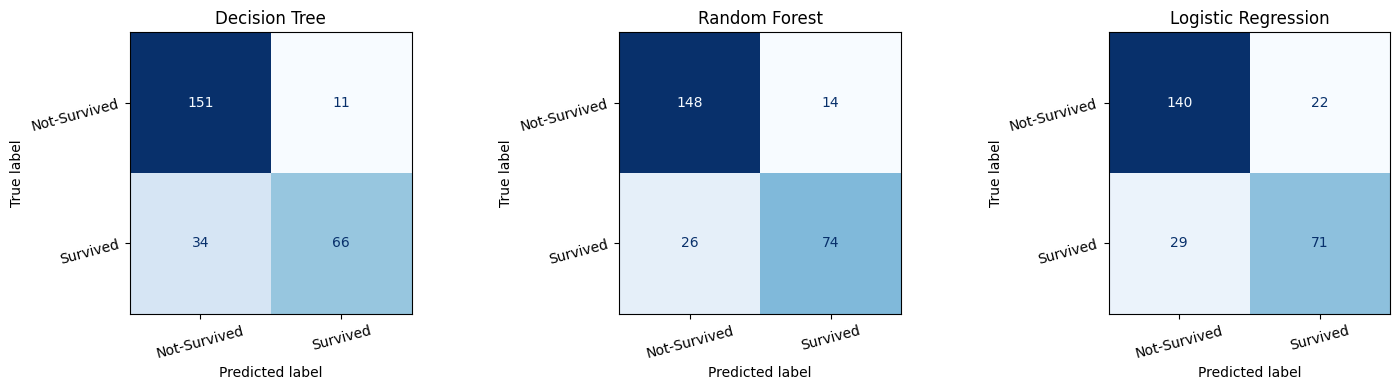

In [13]:
# ── Confusion matrix for the best model ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, y_pred) in zip(axes, [
        ("Decision Tree", y_pred_dt),
        ("Random Forest", y_pred_rf),
        ("Logistic Regression", y_pred_lr)]):
    cmd = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues",
                                                   colorbar=False)
    ax.set_title(model_name)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_yticklabels(labels, rotation=15)
plt.tight_layout()
plt.show()

### 🔍 Part 1 — Reflection Questions

1. Which model achieves the best F1-score for the *Survived* class? Why might this differ from accuracy?
2. What would happen if we fitted the `StandardScaler` on the **entire** dataset before splitting?
3. Can you think of a feature that could improve the model (e.g., combining `sibsp` + `parch`)?

---

## 🔥 Part 2 — Introduction to PyTorch

We will train a neural network on the **Digits dataset** (8×8 grayscale images of handwritten digits, 10 classes).

We'll incrementally build our code from scratch towards idiomatic PyTorch:

| Step | What we add |
|------|-------------|
| 2.1 | Data loading & visualisation |
| 2.2 | Model from scratch (raw tensors) |
| 2.3 | `torch.nn.functional` |
| 2.4 | `nn.Module` + `nn.Linear` |
| 2.5 | `torch.optim` |
| 2.6 | `Dataset` + `DataLoader` |
| 2.7 | Validation loop + early stopping |
| 2.8 | GPU support |

### 2.1 — Data Loading & Visualisation

In [14]:
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────
#### START CODE HERE ####
x, y = load_digits(return_X_y=True, as_frame=True)
n_samples, n_features = x.shape
n_classes = len(np.unique(y))
#### END CODE HERE ####

print(f"Samples: {n_samples} | Features: {n_features} | Classes: {n_classes}")
x.describe()

Samples: 1797 | Features: 64 | Classes: 10


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


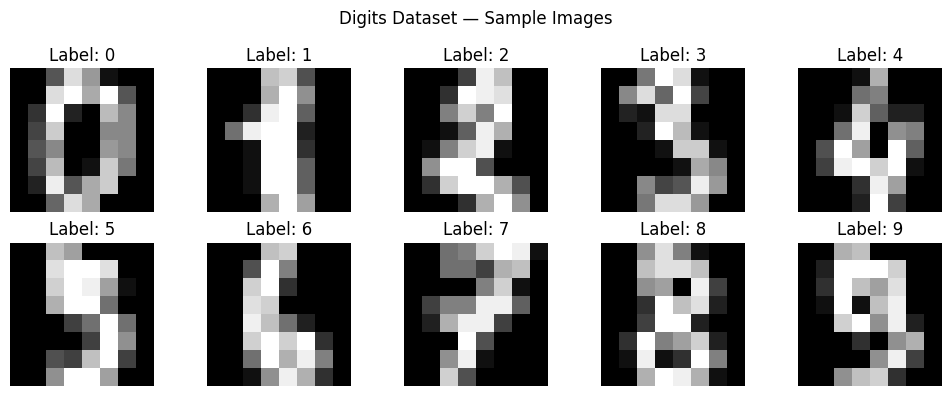

In [15]:
# Visualise a few examples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x.iloc[i].values.reshape(8, 8), cmap='gray')
    ax.set_title(f"Label: {y.iloc[i]}")
    ax.axis('off')
plt.suptitle("Digits Dataset — Sample Images")
plt.tight_layout()
plt.show()

### 2.2 — Preprocessing

In [16]:
#### START CODE HERE ####
# Split 90% train / 10% test, stratified
x_train, x_test, y_train, y_test = train_test_split(
    x.values, y.values, test_size=0.1, stratify=y)
#### END CODE HERE ####

# Normalize to [0, 1] — ALWAYS needed for neural networks
#### START CODE HERE ####
normalizer = MinMaxScaler()
x_train = normalizer.fit_transform(x_train)
x_test  = normalizer.transform(x_test)
#### END CODE HERE ####

print(f"Train: {x_train.shape} | Test: {x_test.shape}")
print(f"Value range — Train: [{x_train.min():.2f}, {x_train.max():.2f}]")

# Convert to PyTorch tensors
x_train = torch.as_tensor(x_train, dtype=torch.float32)
x_test  = torch.as_tensor(x_test,  dtype=torch.float32)
y_train = torch.as_tensor(y_train, dtype=torch.long)
y_test  = torch.as_tensor(y_test,  dtype=torch.long)
print("\n✅ Tensors ready")

Train: (1617, 64) | Test: (180, 64)
Value range — Train: [0.00, 1.00]

✅ Tensors ready


### 2.3 — Model from Scratch (raw tensors)

Before using any PyTorch modules, we implement everything manually:
- **Weights** & **bias** with `requires_grad=True`
- **Forward pass**: matrix multiply + log-softmax
- **Loss**: negative log-likelihood
- **Backward pass**: `loss.backward()`
- **Update**: manual SGD step inside `torch.no_grad()`

In [17]:
# Hyperparameters
lr     = 0.5
epochs = 20
bs     = 64          # mini-batch size
train_samples = x_train.shape[0]

# ── Initialize weights & bias (Xavier-style) ─────────────────
weights = torch.randn(n_features, n_classes) / np.sqrt(n_features)
bias    = torch.randn(n_classes) / np.sqrt(n_features)
weights.requires_grad_()
bias.requires_grad_()

# ── Helper functions ──────────────────────────────────────────
def log_softmax(x):
    return x - x.exp().sum(-1).log().unsqueeze(-1)

def model_scratch(xb):
    return log_softmax(xb @ weights + bias)

def nll_loss(output, target):
    return -output[range(target.shape[0]), target].mean()

def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean() * 100

print(f"Initial loss:     {nll_loss(model_scratch(x_train), y_train):.4f}")
print(f"Initial accuracy: {accuracy(model_scratch(x_train), y_train):.2f}%  (random ≈ {100/n_classes:.1f}%)")

Initial loss:     2.4741
Initial accuracy: 4.33%  (random ≈ 10.0%)


In [18]:
# ── Training loop ────────────────────────────────────────────
for epoch in range(epochs):
    for i in range((train_samples - 1) // bs + 1):
        xb = x_train[i*bs : i*bs+bs]
        yb = y_train[i*bs : i*bs+bs]

        pred = model_scratch(xb)
        loss = nll_loss(pred, yb)
        loss.backward()

        with torch.no_grad():
            weights -= weights.grad * lr
            bias    -= bias.grad    * lr
            weights.grad.zero_()
            bias.grad.zero_()

print(f"Final loss:     {nll_loss(model_scratch(x_train), y_train):.4f}")
print(f"Final accuracy: {accuracy(model_scratch(x_train), y_train):.2f}%")

Final loss:     0.1748
Final accuracy: 96.47%


### 2.4 — Refactor with `nn.Module` + `nn.Linear`

Instead of managing weights manually, we use:
- `nn.Module` — base class for all models
- `nn.Linear` — a fully-connected layer (handles weights + bias automatically)

In [19]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        #### START CODE HERE ####
        self.lin = nn.Linear(n_features, n_classes)
        #### END CODE HERE ####

    def forward(self, xb):
        #### START CODE HERE ####
        return self.lin(xb)
        #### END CODE HERE ####

model = LogisticRegression()
loss_func = F.cross_entropy  # = log_softmax + nll combined

print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Initial loss:     {loss_func(model(x_train), y_train):.4f}")
print(f"Initial accuracy: {accuracy(model(x_train), y_train):.2f}%")

Model parameters: 650
Initial loss:     2.3227
Initial accuracy: 10.14%


### 2.5 — Add `torch.optim`, `Dataset`, `DataLoader`

The **final idiomatic PyTorch training loop** uses:
- `optim.SGD` — takes one optimizer step with `opt.step()` and resets gradients with `opt.zero_grad()`
- `TensorDataset` — wraps tensors into an iterable dataset
- `DataLoader` — handles mini-batching and shuffling automatically

In [20]:
# Build DataLoaders
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

train_ds  = TensorDataset(x_tr, y_tr)
val_ds    = TensorDataset(x_val, y_val)
train_dl  = DataLoader(train_ds, batch_size=bs, shuffle=True)
val_dl    = DataLoader(val_ds,   batch_size=bs*2)

print(f"Train batches: {len(train_dl)} | Val batches: {len(val_dl)}")

Train batches: 23 | Val batches: 2


In [21]:
model = LogisticRegression()
#### START CODE HERE ####
opt = optim.SGD(model.parameters(), lr=lr)
#### END CODE HERE ####

history = {"train_loss": [], "val_loss": [], "val_acc": []}

def fit(model, opt, train_dl, val_dl, epochs=20):
    best_acc, best_state = 0., None

    for epoch in range(epochs):
        # ── Training phase ────────────────────────────────────
        model.train()
        for xb, yb in train_dl:
            pred = model(xb)
            loss = loss_func(pred, yb)
            loss.backward()
            #### START CODE HERE ####
            opt.step()
            opt.zero_grad()
            #### END CODE HERE ####

        # ── Validation phase ──────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_losses, val_accs = [], []
            for xb, yb in val_dl:
                val_losses.append(loss_func(model(xb), yb).item())
                val_accs.append(accuracy(model(xb), yb).item())

        avg_val_loss = np.mean(val_losses)
        avg_val_acc  = np.mean(val_accs)

        # Early stopping: save best model
        if avg_val_acc > best_acc:
            best_acc   = avg_val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(avg_val_acc)

        if epoch % 5 == 0 or epoch == epochs-1:
            print(f"Epoch {epoch:2d} | Val Loss: {avg_val_loss:.3f} | Val Acc: {avg_val_acc:.1f}%")

    # Restore best checkpoint
    model.load_state_dict(best_state)
    print(f"\n✅ Best Val Acc: {best_acc:.2f}%")
    return model

model = fit(model, opt, train_dl, val_dl, epochs=epochs)

Epoch  0 | Val Loss: 1.136 | Val Acc: 84.5%
Epoch  5 | Val Loss: 0.433 | Val Acc: 86.5%
Epoch 10 | Val Loss: 0.355 | Val Acc: 89.8%
Epoch 15 | Val Loss: 0.321 | Val Acc: 90.6%
Epoch 19 | Val Loss: 0.304 | Val Acc: 90.2%

✅ Best Val Acc: 90.60%


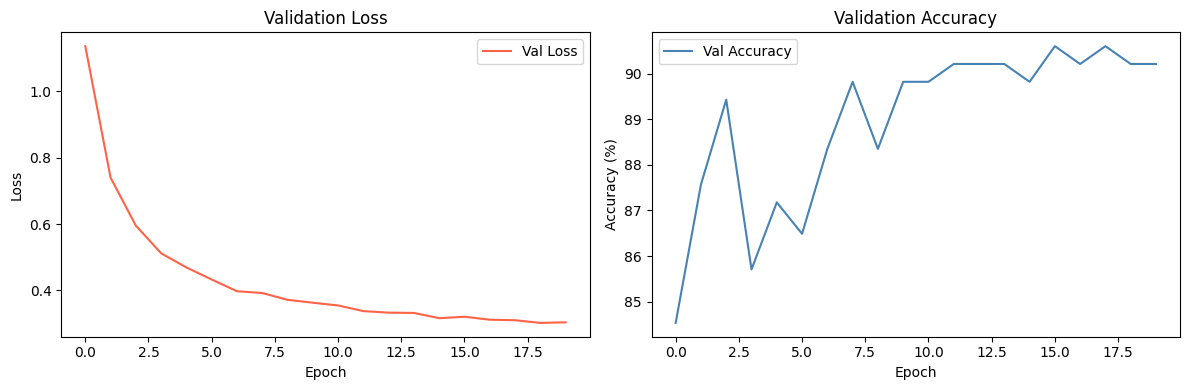

In [22]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["val_loss"], label="Val Loss", color="tomato")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Validation Loss"); ax1.legend()
ax2.plot(history["val_acc"],  label="Val Accuracy", color="steelblue")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.set_title("Validation Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()

In [23]:
# Final evaluation on the TEST set
test_dl = DataLoader(TensorDataset(x_test, y_test), batch_size=bs*2)
model.eval()
with torch.no_grad():
    test_acc = np.mean([accuracy(model(xb), yb).item() for xb, yb in test_dl])
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

🎯 Test Accuracy: 95.94%


### 2.6 — GPU Support

In [24]:
# Detect device
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {dev}")

# To train on GPU, move model and batches to device:
#   model = LogisticRegression().to(dev)
#   xb, yb = xb.to(dev), yb.to(dev)
# Everything else stays the same!

Using device: cuda


### 2.7 — Visualising What the Model Learned

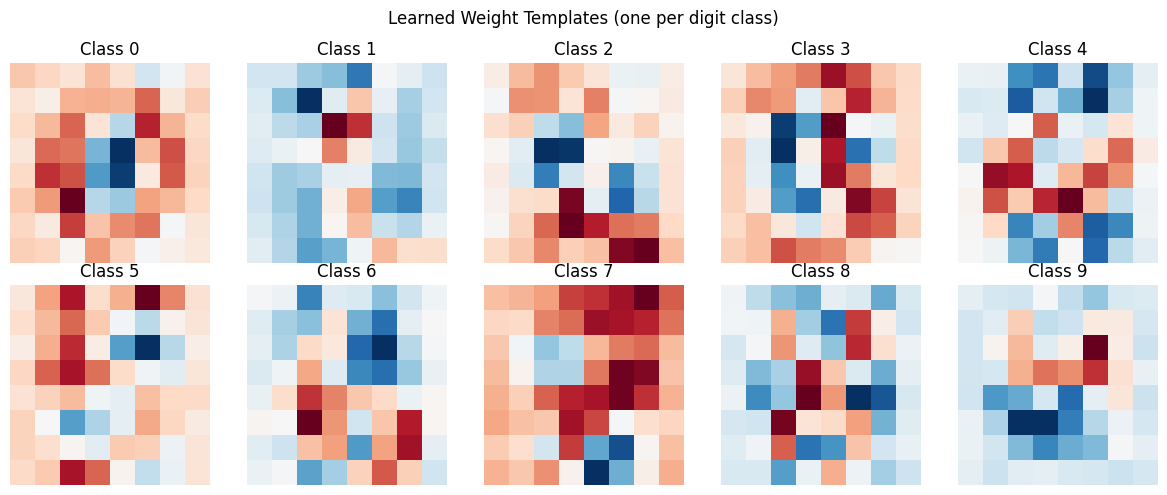

In [25]:
# Weight visualization: each row is the 'template' for one digit class
learnt_weights = model.lin.weight.detach()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(learnt_weights[i].reshape(8, 8), cmap='RdBu_r')
    ax.set_title(f"Class {i}")
    ax.axis('off')
plt.suptitle("Learned Weight Templates (one per digit class)")
plt.tight_layout()
plt.show()

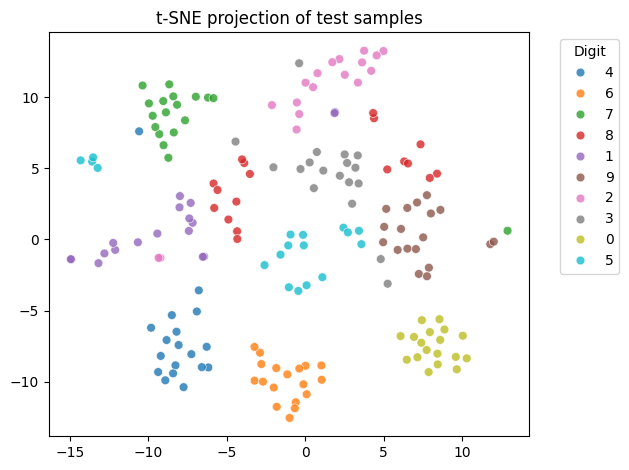

In [26]:
# t-SNE: visualise how well the model separates the classes in feature space
from sklearn.manifold import TSNE
import seaborn as sns

model.eval()
with torch.no_grad():
    projected = TSNE(n_components=2, init='pca', learning_rate='auto',
                     perplexity=30, random_state=42).fit_transform(x_test.numpy())

sns.scatterplot(x=projected[:,0], y=projected[:,1],
                hue=[str(y.item()) for y in y_test],
                palette='tab10', s=40, alpha=0.8)
plt.title("t-SNE projection of test samples")
plt.legend(title="Digit", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

---

## 📝 Summary

### Part 1 — Scikit-learn Pipeline

| Step | Key function |
|------|-------------|
| Split | `train_test_split(..., stratify=y)` |
| Missing values | `fillna()` / `SimpleImputer` |
| Encoding | `LabelEncoder`, `pd.get_dummies` |
| Scaling | `StandardScaler().fit_transform(X_train)` + `.transform(X_test)` |
| Evaluation | `classification_report`, `ConfusionMatrixDisplay` |

### Part 2 — PyTorch

| Component | Purpose |
|-----------|---------|
| `nn.Module` | Base class for models |
| `nn.Linear` | Fully-connected layer |
| `F.cross_entropy` | Combined softmax + NLL loss |
| `torch.optim.SGD` | Gradient descent optimizer |
| `TensorDataset` | Wraps tensors as a dataset |
| `DataLoader` | Auto mini-batching & shuffling |
| `model.train()` / `.eval()` | Toggle training/inference mode |
| `model.state_dict()` | Save/load model weights |

---

### 🔍 Final Reflection Questions

1. Why should you **never** fit a scaler on the test set?
2. In PyTorch, what does `loss.backward()` compute? What does `opt.zero_grad()` do and why is it necessary?
3. When is early stopping useful? What is its risk?
4. What is the difference between `model.train()` and `model.eval()`?
